In [1]:
# Standard library imports
import importlib
import re
import json

# Local helper module
import utils
#importlib.reload(utils)

In [2]:
df = utils.load_and_prepare_data('coffee_sales.csv')
utils.print_html(df.sample(n=10), title="Coffee Sales Data")

date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-03-11,08:56,cash,NaN,3.000,Americano,1,3,2024
2024-04-16,11:50,card,ANON-0000-0000-0064,2.890,Cortado,2,4,2024
2024-05-25,13:43,card,ANON-0000-0000-0212,3.282,Americano with Milk,2,5,2024
2024-10-04,09:08,card,ANON-0000-0000-0003,2.596,Americano,4,10,2024
2024-11-10,16:24,card,ANON-0000-0000-0884,3.576,Cappuccino,4,11,2024
2024-08-19,10:19,card,ANON-0000-0000-0507,3.282,Latte,3,8,2024
2024-05-22,16:25,card,ANON-0000-0000-0180,3.772,Hot Chocolate,2,5,2024
2024-04-29,11:35,card,ANON-0000-0000-0141,3.282,Americano with Milk,2,4,2024
2025-02-20,06:51,card,ANON-0000-0000-1161,3.576,Cappuccino,1,2,2025
2025-02-11,14:53,card,ANON-0000-0000-1163,3.576,Latte,1,2,2025


In [3]:
def generate_chart_code(instruction: str, model: str, out_path_v1: str) -> str:
    """Generate Python code to make a plot with matplotlib using tag-based wrapping."""

    prompt = f"""
    You are a data visualization expert.

    Return your answer *strictly* in this format:

    <execute_python>
    # valid python code here
    </execute_python>

    Do not add explanations, only the tags and the code.

    The code should create a visualization from a DataFrame 'df' with these columns:
    - date   (datetime64 — already parsed; use df['date'].dt.year, df['date'].dt.month, etc.)
    - time   (string, HH:MM — do NOT concatenate or combine with the date column)
    - cash_type (string: 'card' or 'cash')
    - card (string)
    - price (number)
    - coffee_name (string)
    - quarter (int, 1–4 — already computed, use directly)
    - month  (int, 1–12 — already computed, use directly)
    - year   (int, e.g. 2024 — already computed, use directly)

    User instruction: {instruction}

    Requirements for the code:
    1. Assume the DataFrame is already loaded as 'df'.
    2. Use matplotlib for plotting.
    3. Add clear title, axis labels, and legend if needed.
    4. Save the figure as '{out_path_v1}' with dpi=300.
    5. Do not call plt.show().
    6. Close all plots with plt.close().
    7. Add all necessary import python statements
    8. CRITICAL: 'date' is datetime64 — never use string concatenation on it.
       Filter by year/quarter using the 'year' and 'quarter' integer columns.
    
    Return ONLY the code wrapped in <execute_python> tags.
    """

    response = utils.get_response(model, prompt)
    return response

In [4]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model="gpt-4o-mini", 
    out_path_v1="chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")


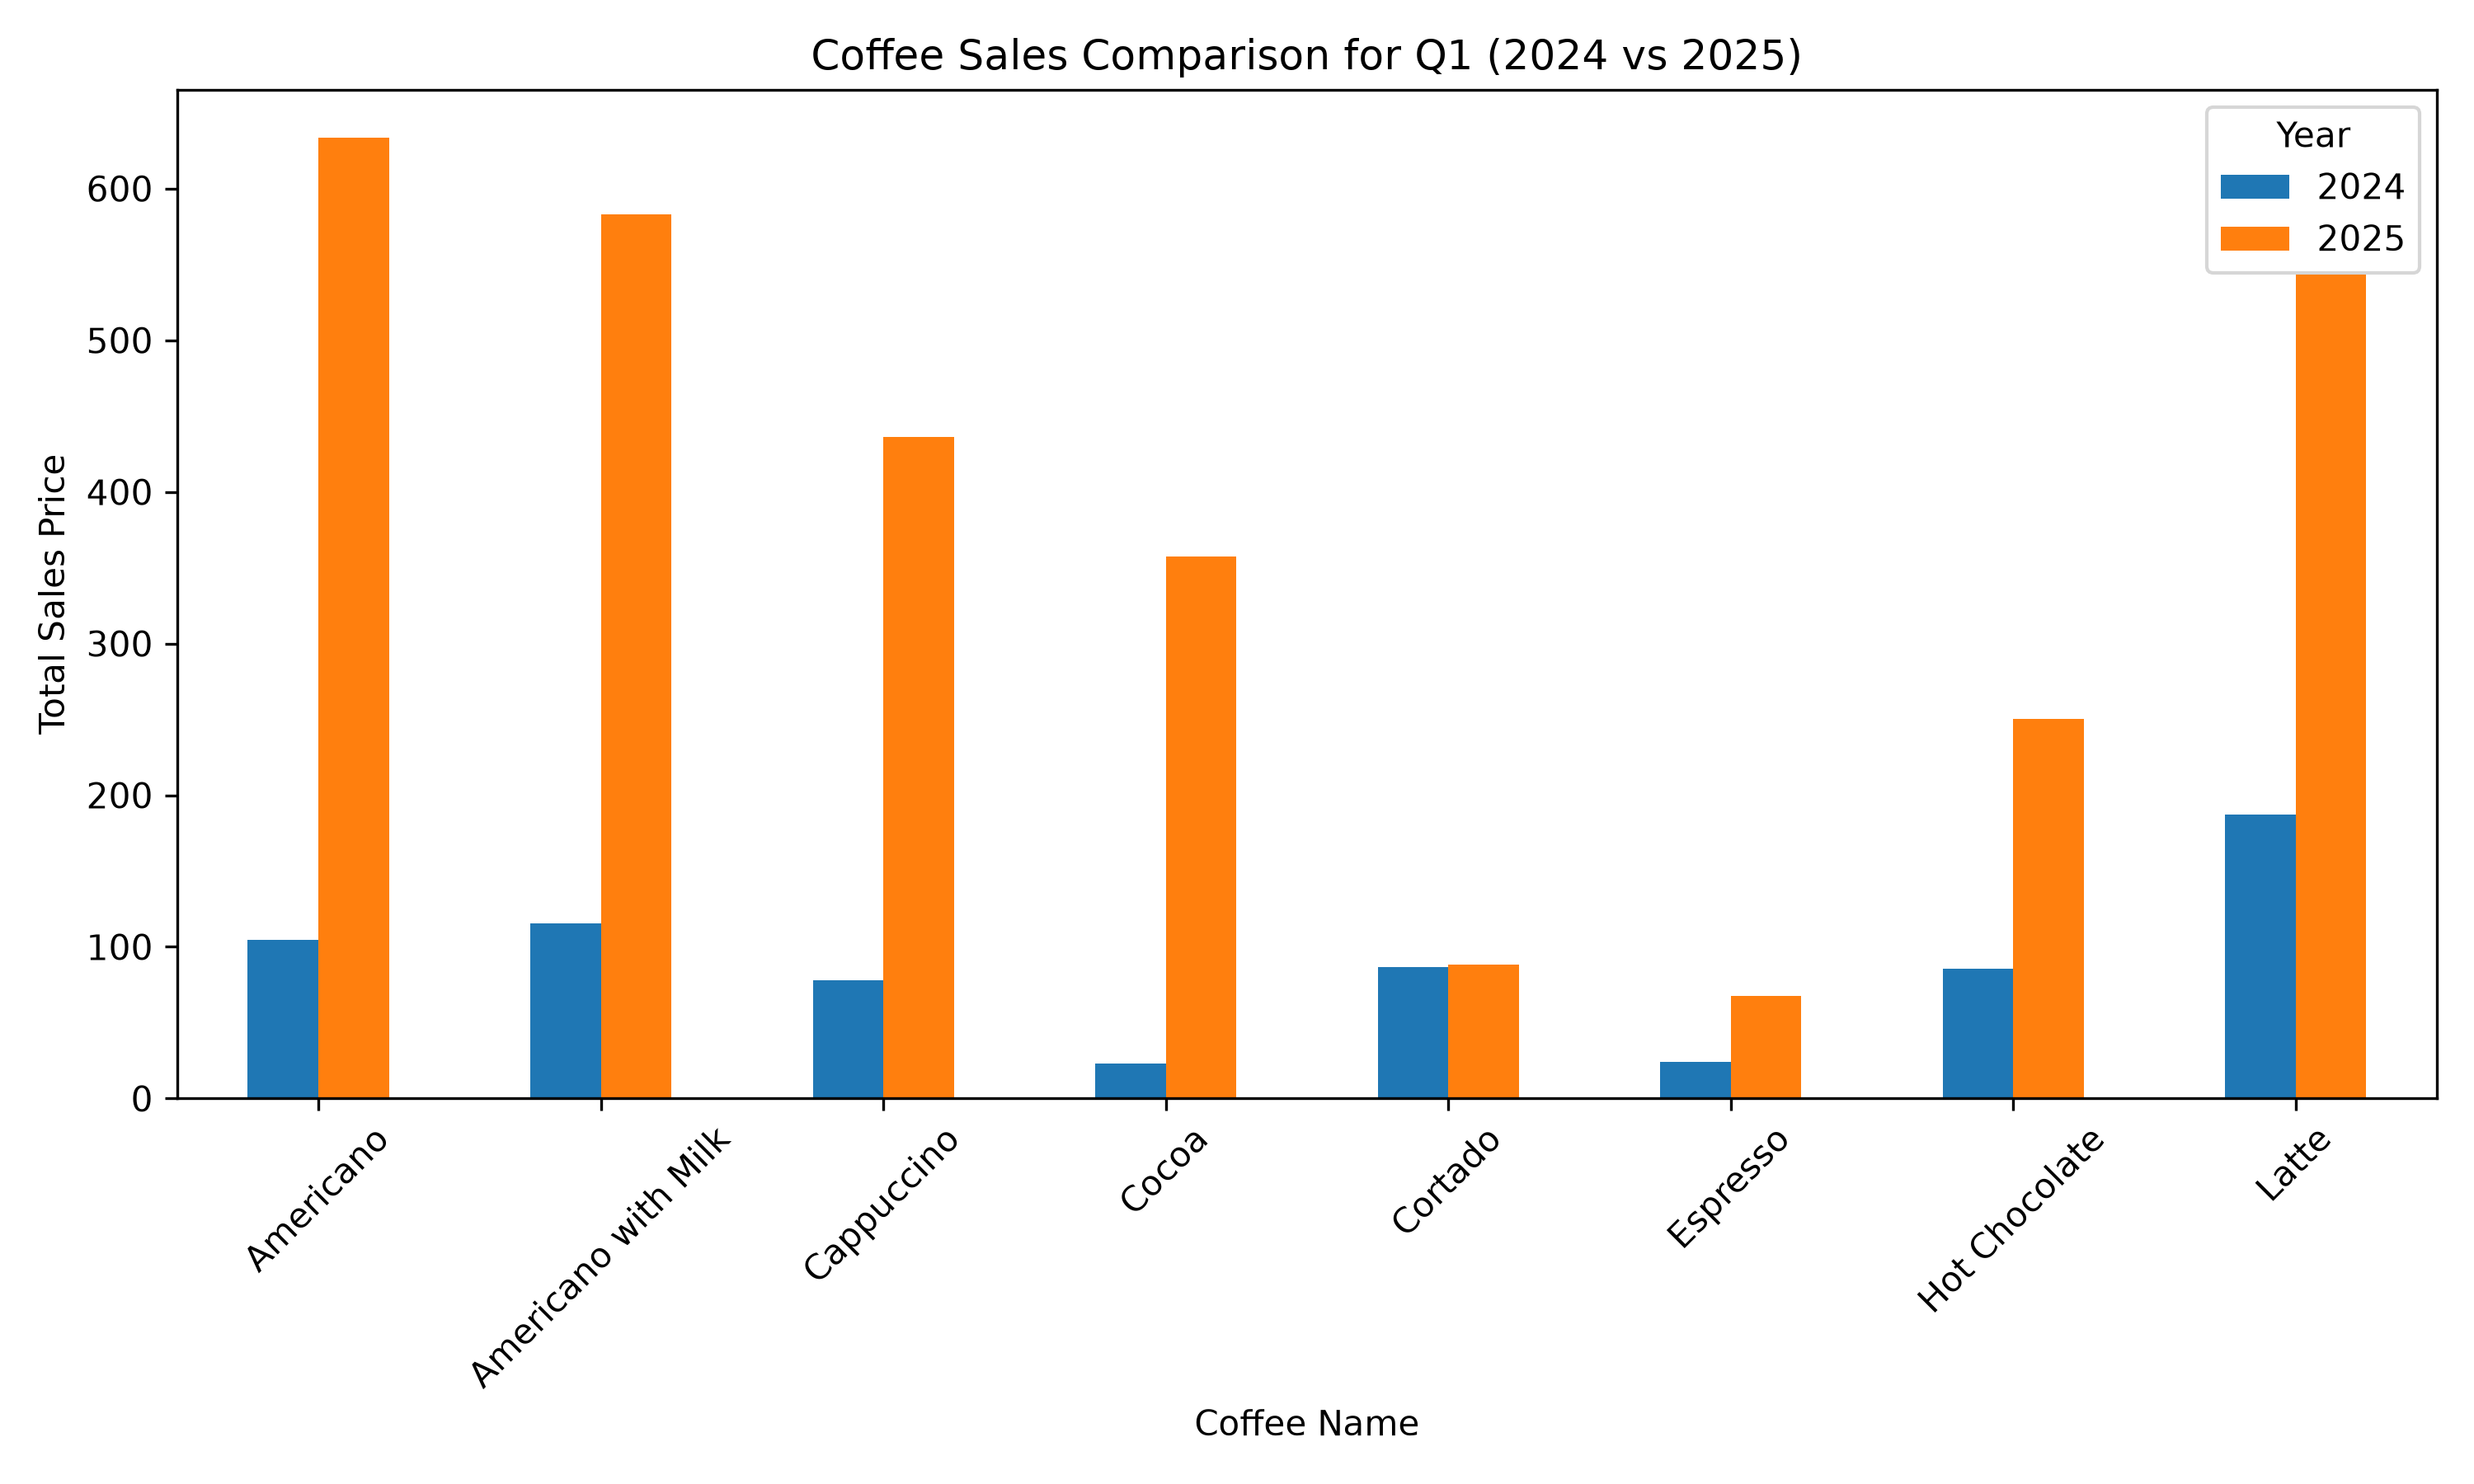

In [5]:
# Get code within the <execute_python> tags
match = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1) 
if match:
    initial_code = match.group(1).strip()
    utils.print_html(initial_code, title="Extracted Python code")
    exec_global = {"df": df}  # Provide the DataFrame in the global scope for exec
    exec(initial_code, exec_global)

# If code run successfully, the file chart_v1.png should have been generated
utils.print_html(
    content="chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)


In [ ]:
def reflect_on_image_and_regenerate(
    chart_path: str,
    instruction: str,
    model_name: str,
    out_path_v2: str,
    code_v1: str,  
) -> tuple[str, str]:
    """
    Critique the chart IMAGE and the original code against the instruction, 
    then return refined matplotlib code.
    Returns (feedback, refined_code_with_tags).
    Supports OpenAI and Anthropic (Claude).
    """
    media_type, b64 = utils.encode_image_b64(chart_path)
    

    prompt = f"""
    You are a data visualization expert.
    Your task: critique the attached chart and the original code against the given instruction,
    then return improved matplotlib code.

    Original code (for context):
    {code_v1}

    OUTPUT FORMAT (STRICT):
    1) First line: a valid JSON object with ONLY the "feedback" field.
    Example: {{"feedback": "The legend is unclear and the axis labels overlap."}}

    2) After a newline, output ONLY the refined Python code wrapped in:
    <execute_python>
    ...
    </execute_python>

    3) Import all necessary libraries in the code. Don't assume any imports from the original code.

    HARD CONSTRAINTS:
    - Do NOT include Markdown, backticks, or any extra prose outside the two parts above.
    - Use pandas/matplotlib only (no seaborn).
    - Assume df already exists; do not read from files.
    - Save to '{out_path_v2}' with dpi=300.
    - Always call plt.close() at the end (no plt.show()).
    - Include all necessary import statements.
    
    IMPORTANT: The 'date' column is already a pandas datetime64 type.
    - Do NOT concatenate 'date' with 'time' using string operations.
    - To filter by year/quarter, use: df[df['year'] == 2024] or df['date'].dt.year == 2024
    - The 'quarter' and 'year' columns already exist as integers; use them directly.

    Schema (columns available in df):
    - date   (datetime64 — already parsed; use df['date'].dt.year, etc.)
    - time   (string, HH:MM — do NOT concatenate with date)
    - cash_type (string: 'card' or 'cash')
    - card   (string)
    - price  (float)
    - coffee_name (string)
    - quarter (int, 1–4)
    - month  (int, 1–12)
    - year   (int)
    
    CRITICAL TYPE RULE: 'date' is already datetime64.
    - NEVER do: df['date'] + ' ' + df['time']  ← this will crash
    - ALWAYS filter by year/quarter using the integer columns: df[df['year'] == 2024]

    Instruction:
    {instruction}
    """
    content = utils.image_openai_call(model_name, prompt, media_type, b64)

    # --- Parse ONLY the first JSON line (feedback) ---
    lines = content.strip().splitlines()
    json_line = lines[0].strip() if lines else ""
    try:
        obj = json.loads(json_line)
    except Exception as e:
        # Fallback: try to capture the first {...} in all the content
        m_json = re.search(r"\{.*?\}", content, flags=re.DOTALL)
        if m_json:
            try:
                obj = json.loads(m_json.group(0))
            except Exception as e2:
                obj = {"feedback": f"Failed to parse JSON: {e2}"}
        else:
            obj = {"feedback": f"Failed to parse JSON: {e}"}
    # --- Extract refined code from <execute_python>...</execute_python> ---
    m_code = re.search(r"<execute_python>([\s\S]*?)</execute_python>", content)
    refined_code_body = m_code.group(1).strip() if m_code else ""
    refined_code = utils.ensure_execute_python_tags(refined_code_body)

    feedback = str(obj.get("feedback", "")).strip()
    return feedback, refined_code


In [7]:
# Generate feedback alongside reflected code
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="chart_v1.png",            
    instruction="Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv.", 
    model_name="o4-mini",
    out_path_v2="chart_v2.png",
    code_v1=code_v1,   # pass in the original code for context        
)

utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")

TypeError: image_openai_call() got an unexpected keyword argument 'model'